In [ ]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-learn
!pip install yfinance

In [ ]:

# Importação de bibliotecas

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf

from scipy.stats import norm
from sklearn.ensemble import IsolationForest

In [ ]:
#configuração esteteica do searborn
sns.set_theme(style="darkgrid")

In [ ]:
tickers = ['PETR4.SA', 'VALE3.SA', 'ITUB4.SA', 'BBDC4.SA', 'ABEV3.SA','WEGE3.SA','EMBJ3.SA']
data_inicio = "2022-01-01"
data_fim = "2026-01-20"
investimento_total = 100000

# Download dos dados de fechamento via Yahoo Finance
print(f"Baixando dados para: {tickers}...")
df = yf.download(tickers, start=data_inicio, end=data_fim)['Close']

Baixando dados para: ['PETR4.SA', 'VALE3.SA', 'ITUB4.SA', 'BBDC4.SA', 'ABEV3.SA', 'WEGE3.SA', 'EMBJ3.SA']...


/tmp/ipython-input-2415641148.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start=data_inicio, end=data_fim)['Close']
[*********************100%***********************]  7 of 7 completed


In [ ]:
returns = np.log(df / df.shift(1)).dropna()

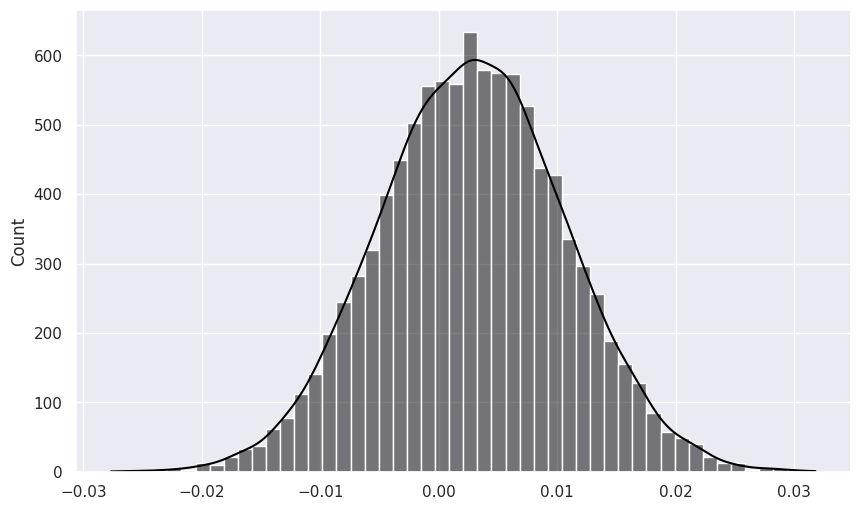

In [ ]:

def calcular_monte_carlo_var(returns, investimento_total=100000, simulacoes=10000):
    """
    Estima o VaR e CVaR via Simulação de Monte Carlo.
    Estimates VaR and CVaR via Monte Carlo Simulation.
    """
    media_retornos = returns.mean()
    cov_matrix = returns.cov()

    # Decomposição de Cholesky para manter as correlações históricas entre ativos

    L = np.linalg.cholesky(cov_matrix)

    # Geração de caminhos aleatórios (Ruído Branco)
    z = np.random.normal(size=(simulacoes, len(tickers)))
    retornos_simulados = media_retornos.values + np.dot(z, L.T)

    # Cálculo do retorno da carteira (Equiponderada)
    pesos = np.array([1/len(tickers)] * len(tickers))
    retornos_carteira = np.dot(retornos_simulados, pesos)

    # Cálculo das métricas de risco (Percentil 5%)
    var_95 = np.percentile(retornos_carteira, 5)
    cvar_95 = retornos_carteira[retornos_carteira <= var_95].mean()

    return var_95, cvar_95, retornos_carteira

# Execução da simulação

var_95, cvar_95, sim_results = calcular_monte_carlo_var(returns, investimento_total)

plt.figure(figsize=(10, 6))
sns.histplot(sim_results, bins=50, kde=True, color='black')
plt.show()

In [ ]:

print(f"\nAtivos disponíveis: {tickers}")
selecao = input("Analise anomalias em (ex: PETR4): ").strip().upper()
asset_to_analyze = selecao if ".SA" in selecao else f"{selecao}.SA"

if asset_to_analyze in returns.columns:
    asset_data = returns[[asset_to_analyze]].copy()

    # Inicialização do Isolation Forest (IA Não Supervisionada)

    # Contamination=0.03 define que esperamos 3% de outliers

    iso_forest = IsolationForest(contamination=0.03, random_state=42)
    asset_data['anomaly'] = iso_forest.fit_predict(asset_data)

    # Filtragem dos pontos identificados como anômalos (-1)

    anomalias = asset_data[asset_data['anomaly'] == -1]


Ativos disponíveis: ['PETR4.SA', 'VALE3.SA', 'ITUB4.SA', 'BBDC4.SA', 'ABEV3.SA', 'WEGE3.SA', 'EMBJ3.SA']
Analise anomalias em (ex: PETR4): EMBJ3.SA


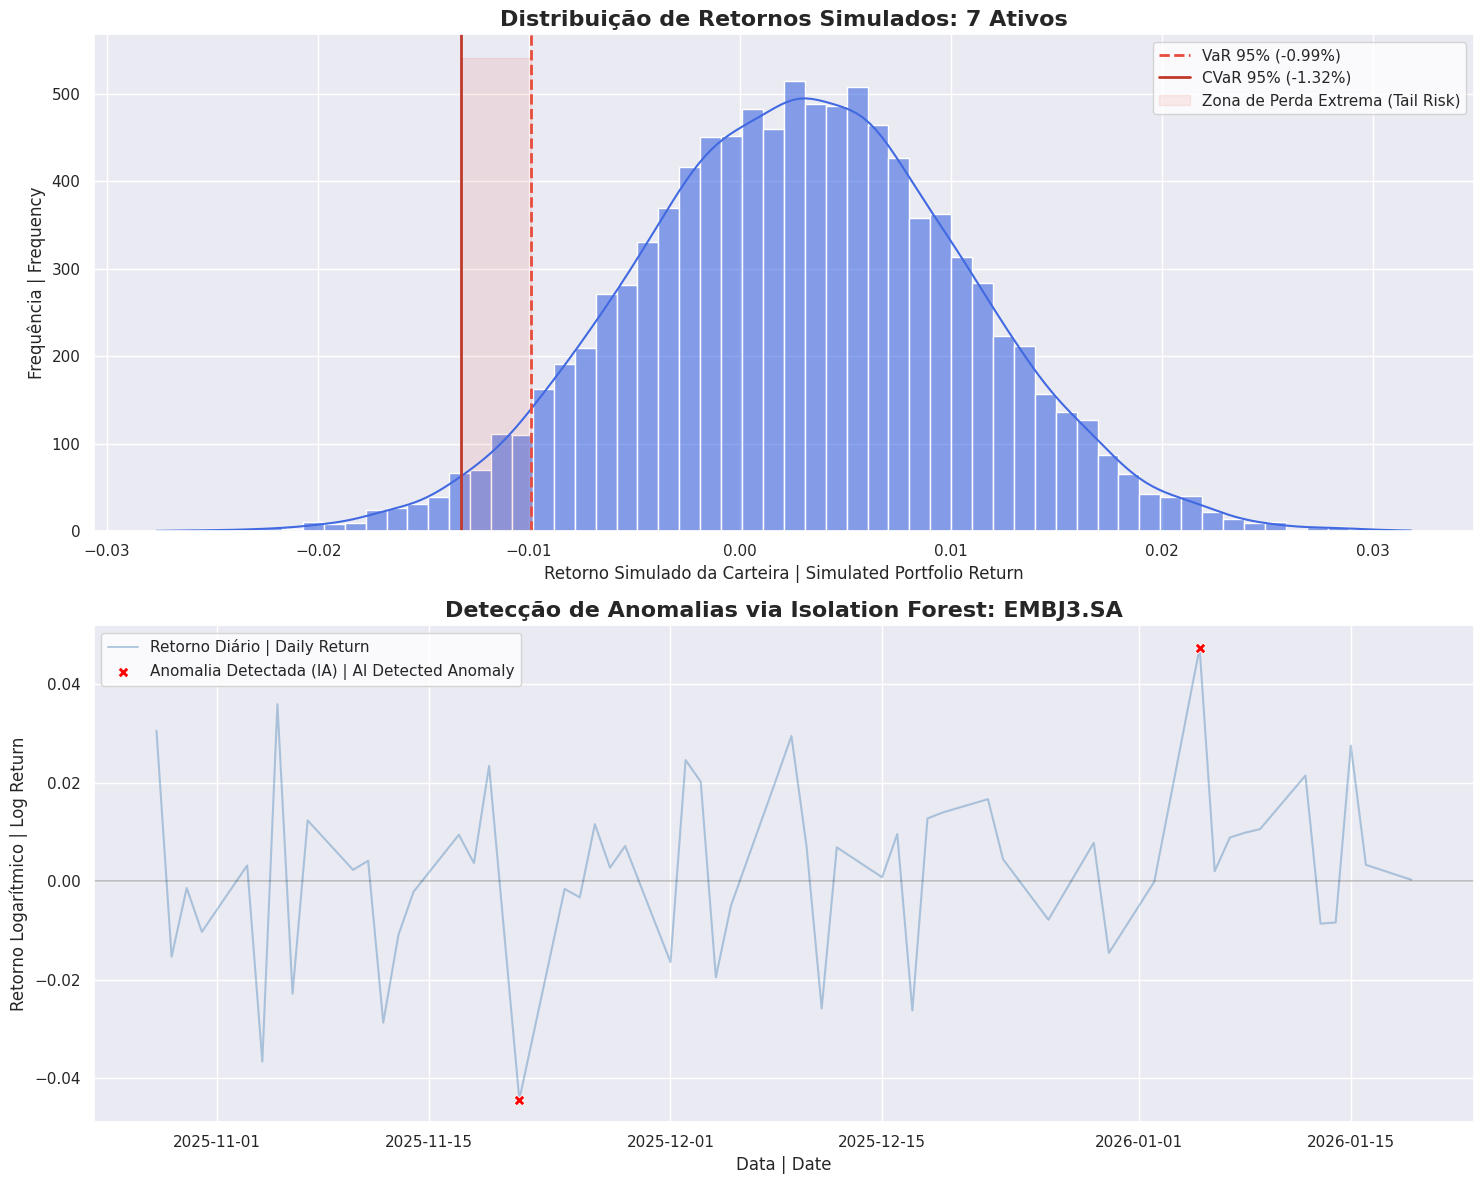

In [ ]:
plt.figure(figsize=(15, 12))

# Subplot 1: Histograma e Densidade do Risco (Monte Carlo)
plt.subplot(2, 1, 1)
sns.histplot(sim_results, bins=60, kde=True, color='royalblue', edgecolor='white', alpha=0.6)

# Adicionando linhas verticais para VaR e CVaR (Métricas de Risco)
plt.axvline(var_95, color='#e74c3c', linestyle='--', linewidth=2, label=f'VaR 95% ({var_95:.2%})')
plt.axvline(cvar_95, color='#c0392b', linestyle='-', linewidth=2, label=f'CVaR 95% ({cvar_95:.2%})')

# Realce visual da "Cauda de Risco"
plt.fill_betweenx(plt.ylim(), cvar_95, var_95, color='#e74c3c', alpha=0.1, label='Zona de Perda Extrema (Tail Risk)')

plt.title(f"Distribuição de Retornos Simulados: {len(tickers)} Ativos", fontsize=16, fontweight='bold')
plt.xlabel("Retorno Simulado da Carteira | Simulated Portfolio Return", fontsize=12)
plt.ylabel("Frequência | Frequency", fontsize=12)
plt.legend(frameon=True, facecolor='white')

# Subplot 2: Série Temporal e Anomalias Detectadas pela IA
plt.subplot(2, 1, 2)
sns.lineplot(x=returns.index, y=returns[asset_to_analyze], color='steelblue', alpha=0.4, label='Retorno Diário | Daily Return')

# Plotagem das anomalias com marcador de destaque (X vermelho)
sns.scatterplot(x=anomalias.index, y=anomalias[asset_to_analyze], color='red', s=60,
                label='Anomalia Detectada (IA) | AI Detected Anomaly', marker='X', zorder=5)

plt.title(f"Detecção de Anomalias via Isolation Forest: {asset_to_analyze}", fontsize=16, fontweight='bold')
plt.xlabel("Data | Date", fontsize=12)
plt.ylabel("Retorno Logarítmico | Log Return", fontsize=12)
plt.axhline(0, color='black', linestyle='-', alpha=0.2)
plt.legend(frameon=True, facecolor='white')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*50)
print("📊 RELATÓRIO FINAL DE RISCO | FINAL RISK REPORT")
print("="*50)
print(f"Investimento Base | Base Investment: R$ {investimento_total:,.2f}")
print(f"VaR 95% (Risco Máximo Diário): R$ {abs(var_95 * investimento_total):,.2f}")
print(f"CVaR 95% (Expectativa em Crise): R$ {abs(cvar_95 * investimento_total):,.2f}")
print(f"Anomalias no Ativo {asset_to_analyze}: {len(anomalias)} pontos")
print("="*50)


📊 RELATÓRIO FINAL DE RISCO | FINAL RISK REPORT
Investimento Base | Base Investment: R$ 100,000.00
VaR 95% (Risco Máximo Diário): R$ 990.99
CVaR 95% (Expectativa em Crise): R$ 1,323.49
Anomalias no Ativo EMBJ3.SA: 2 pontos
